# Notebook 6 NER Phase 2: Post-Normalization
**Luis Mitrovic Balbontín Archive**

Reproduces the Phase 2 NER visualizations using the normalized entity dataset.
Normalization was applied in two stages: automatic consolidation of unambiguous
variants, followed by manual close reading resolution of ambiguous cases including
all 15 German-language letters. One duplicate removed (S043-003 = S079-001),
reducing the corpus from 50 to 49 documents.

**Inputs:**
- `data/processed/NER_normalized_clean.csv` — normalized entity dataset (n=49)
- `data/processed/NER_normalized_clean_dates.csv` — same dataset with parsed dates

**Outputs:**
- `figures/fig7_ner_distribution_postnorm_A.png` — total entity mentions per document
- `figures/fig8_ner_distribution_postnorm_B.png` — entity composition per document
- `figures/fig9_top15_entities_postnorm.png` — top 15 entities per type (3 panels vertical)
- `figures/fig10_entity_prominence_postnorm.png` — bubble chart: prominence vs frequency
- `figures/fig11_pre_post_normalization.png` — pre vs post normalization comparison

In [1]:
from pathlib import Path

BASE       = Path.cwd().parent
DATA_RAW   = BASE / "data" / "raw"
DATA_PROC  = BASE / "data" / "processed"
FIGURES    = BASE / "figures"

for folder in [DATA_PROC, FIGURES]:
    folder.mkdir(parents=True, exist_ok=True)

print(f"DATA_PROC: {DATA_PROC}")
print(f"FIGURES:   {FIGURES}")

DATA_PROC: C:\Users\felip\mitrovic-archive\data\processed
FIGURES:   C:\Users\felip\mitrovic-archive\figures


In [2]:
# Imports 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from pathlib import Path
from collections import Counter
from adjustText import adjust_text
import warnings
warnings.filterwarnings("ignore")

# Paths
DATA_FILE = DATA_PROC / "NER_normalized_clean.csv"

# Global matplotlib settings 
plt.rcParams.update({
    "font.family"    : "serif",
    "font.size"      : 10,
    "axes.titlesize" : 11,
    "axes.labelsize" : 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "figure.dpi"     : 300,
    "savefig.dpi"    : 300,
    "savefig.bbox"   : "tight",
})

# Load CSV 
for enc in ["utf-8-sig", "utf-8", "latin-1"]:
    try:
        df = pd.read_csv(DATA_FILE, encoding=enc, sep=";",
                         quotechar='"', quoting=0, engine="python")
        print(f"Encoding detected : {enc}")
        break
    except Exception as e:
        print(f"  Failed {enc}: {e}")

# Drop empty rows
df = df.dropna(how="all")
df = df[df["doc_id"].notna()].reset_index(drop=True)

# Inspection
print(f"\n── Shape ──────────────────────────────────────────")
print(f"  {df.shape[0]} documents × {df.shape[1]} columns\n")
print("── Columns ────────────────────────────────────────")
print(df.dtypes.to_string())
print("\n── First rows ─────────────────────────────────────")
df[["doc_id", "Envelope", "Language", "Notes"]].head(10)

Encoding detected : utf-8-sig

── Shape ──────────────────────────────────────────
  49 documents × 7 columns

── Columns ────────────────────────────────────────
doc_id            str
Envelope          str
Language          str
PER_normalized    str
LOC_normalized    str
ORG_normalized    str
Notes             str

── First rows ─────────────────────────────────────


,doc_id,Envelope,Language,Notes
0,S68-003,S68,German,Se realizó NER manual sobre la carta
1,S72-003,S72,German,Se realizó NER manual sobre la carta
2,S73-002,S73,German,Se realizó NER manual sobre la carta
3,S76-003,S76,German,Se realizó NER manual sobre la carta
4,S77-001,S77,German,Se realizó NER manual sobre la carta
5,S78-003,S78,German,Se realizó NER manual sobre la carta
6,S79-001,S79,German,Se realizó NER manual sobre la carta
7,S80-003,S80,German,Se realizó NER manual sobre la carta
8,S81-003,S81,German,Se realizó NER manual sobre la carta
9,S82-003,S82,German,Se realizó NER manual sobre la carta


In [3]:
# Diagnose entity columns 
print("── Raw values sample ───────────────────────────────")
for col in ["PER_normalized", "LOC_normalized", "ORG_normalized"]:
    print(f"\n{col}:")
    print(df[col].head(10).to_string())

print("\n── Null counts ─────────────────────────────────────")
print(df[["PER_normalized", "LOC_normalized", "ORG_normalized"]].isna().sum())

── Raw values sample ───────────────────────────────

PER_normalized:
0    Luis;Adolf Hitler;Hermann Göring;Rolf Altenburger
1    Luis;Wilhelm Gustloff;John;Bubi Laub;John;Bubi...
2                     Luis;Spengemann;Rolf Altenburger
3                          Luis;Pia;John Dijkstra;Luis
4    Luis;Frau Avenarius;Frau Avenarius;Pepi zu Doh...
5    Luis;Grieg;Peter Behrens;Wynold Tjark Reiss;Ec...
6    Luis;Rolf Altenburger;Marc Rich;Schmidheiny;Pi...
7    Luis;Miss Italia;Miss Italia;Erfurt;Petersen;E...
8    Luis;Spengemann;Adolf Hitler;Spengemann;Picass...
9                         Fritz Schumacher;Paul Bonatz

LOC_normalized:
0    Switzerland;Düsseldorf;Ruhr;Germany;Germany;So...
1    Wuppertal;Ruhr;Düsseldorf;Essen;Dortmund;Scotl...
2                Spanish;Spain;Portugal;Belgium;Vienna
3                     Solothurn;Santiago;Chile;Germany
4    Solothurn;Switzerland;Thun;Bern;Solothurn;Muni...
5    Hamburg;Vienna;Germany;Santiago;Solothurn;Swit...
6    Solothurn;Chile;Bern;Zurich;

In [4]:
# Parse entity lists from semicolon-separated strings
# Empty cells (NaN) treated as empty lists
# Strip whitespace from each entity

def parse_entities(cell):
    if pd.isna(cell) or str(cell).strip() == "":
        return []
    return [e.strip() for e in str(cell).split(";") if e.strip() != ""]

df["PER"] = df["PER_normalized"].apply(parse_entities)
df["LOC"] = df["LOC_normalized"].apply(parse_entities)
df["ORG"] = df["ORG_normalized"].apply(parse_entities)

# Counts
df["PER_count"]      = df["PER"].apply(len)
df["LOC_count"]      = df["LOC"].apply(len)
df["ORG_count"]      = df["ORG"].apply(len)
df["total_entities"] = df["PER_count"] + df["LOC_count"] + df["ORG_count"]

df["PER_unique"]  = df["PER"].apply(lambda x: len(set(x)))
df["LOC_unique"]  = df["LOC"].apply(lambda x: len(set(x)))
df["ORG_unique"]  = df["ORG"].apply(lambda x: len(set(x)))
df["total_unique"] = df["PER_unique"] + df["LOC_unique"] + df["ORG_unique"]

# Summary
print("── Corpus summary ──────────────────────────────────")
print(f"  Documents         : {len(df)}")
print(f"\n── Mentions ────────────────────────────────────────")
print(f"  PER  : {df['PER_count'].sum()}")
print(f"  LOC  : {df['LOC_count'].sum()}")
print(f"  ORG  : {df['ORG_count'].sum()}")
print(f"  Total: {df['total_entities'].sum()}")
print(f"\n── Unique entities ─────────────────────────────────")
print(f"  PER  : {df['PER_unique'].sum()}")
print(f"  LOC  : {df['LOC_unique'].sum()}")
print(f"  ORG  : {df['ORG_unique'].sum()}")
print(f"  Total: {df['total_unique'].sum()}")
print(f"\n── Language distribution ───────────────────────────")
print(df["Language"].value_counts().to_string())

── Corpus summary ──────────────────────────────────
  Documents         : 49

── Mentions ────────────────────────────────────────
  PER  : 456
  LOC  : 586
  ORG  : 130
  Total: 1172

── Unique entities ─────────────────────────────────
  PER  : 344
  LOC  : 425
  ORG  : 112
  Total: 881

── Language distribution ───────────────────────────
Language
Spanish    27
German     14
English     8


In [5]:
# Shared visual variables

# Color palette
C_PER = "#2E8B57"
C_LOC = "#E07B39"
C_ORG = "#4A6FA5"

# Grayscale — language
LANG_COLORS_GRAY = {
    "Spanish": "#1a1a1a",
    "English": "#888888",
    "German" : "#d4d4d4",
}

# Sort by total_entities descending
df_fig = df.sort_values("total_entities", ascending=False).reset_index(drop=True)

# Axis values
y      = np.arange(len(df_fig))
labels = df_fig["doc_id"].tolist()

# Bar colors by language
bar_colors_gray = [LANG_COLORS_GRAY[lang] for lang in df_fig["Language"]]

# Edge colors — German border
edge_colors = ["#555555" if lang == "German" else "white"
               for lang in df_fig["Language"]]
edge_widths = [1.0 if lang == "German" else 0.3
               for lang in df_fig["Language"]]

# Legend patches Panel A
patch_es = mpatches.Patch(color=LANG_COLORS_GRAY["Spanish"], label="Spanish")
patch_en = mpatches.Patch(color=LANG_COLORS_GRAY["English"], label="English")
patch_de = mpatches.Patch(color=LANG_COLORS_GRAY["German"],  label="German (NER manual)")

print(f"Documents : {len(df_fig)}")
print(f"Order (first 5): {labels[:5]}")

Documents : 49
Order (first 5): ['S179-003', 'S72-003', 'S67-003', 'S41-001', 'S83-003']


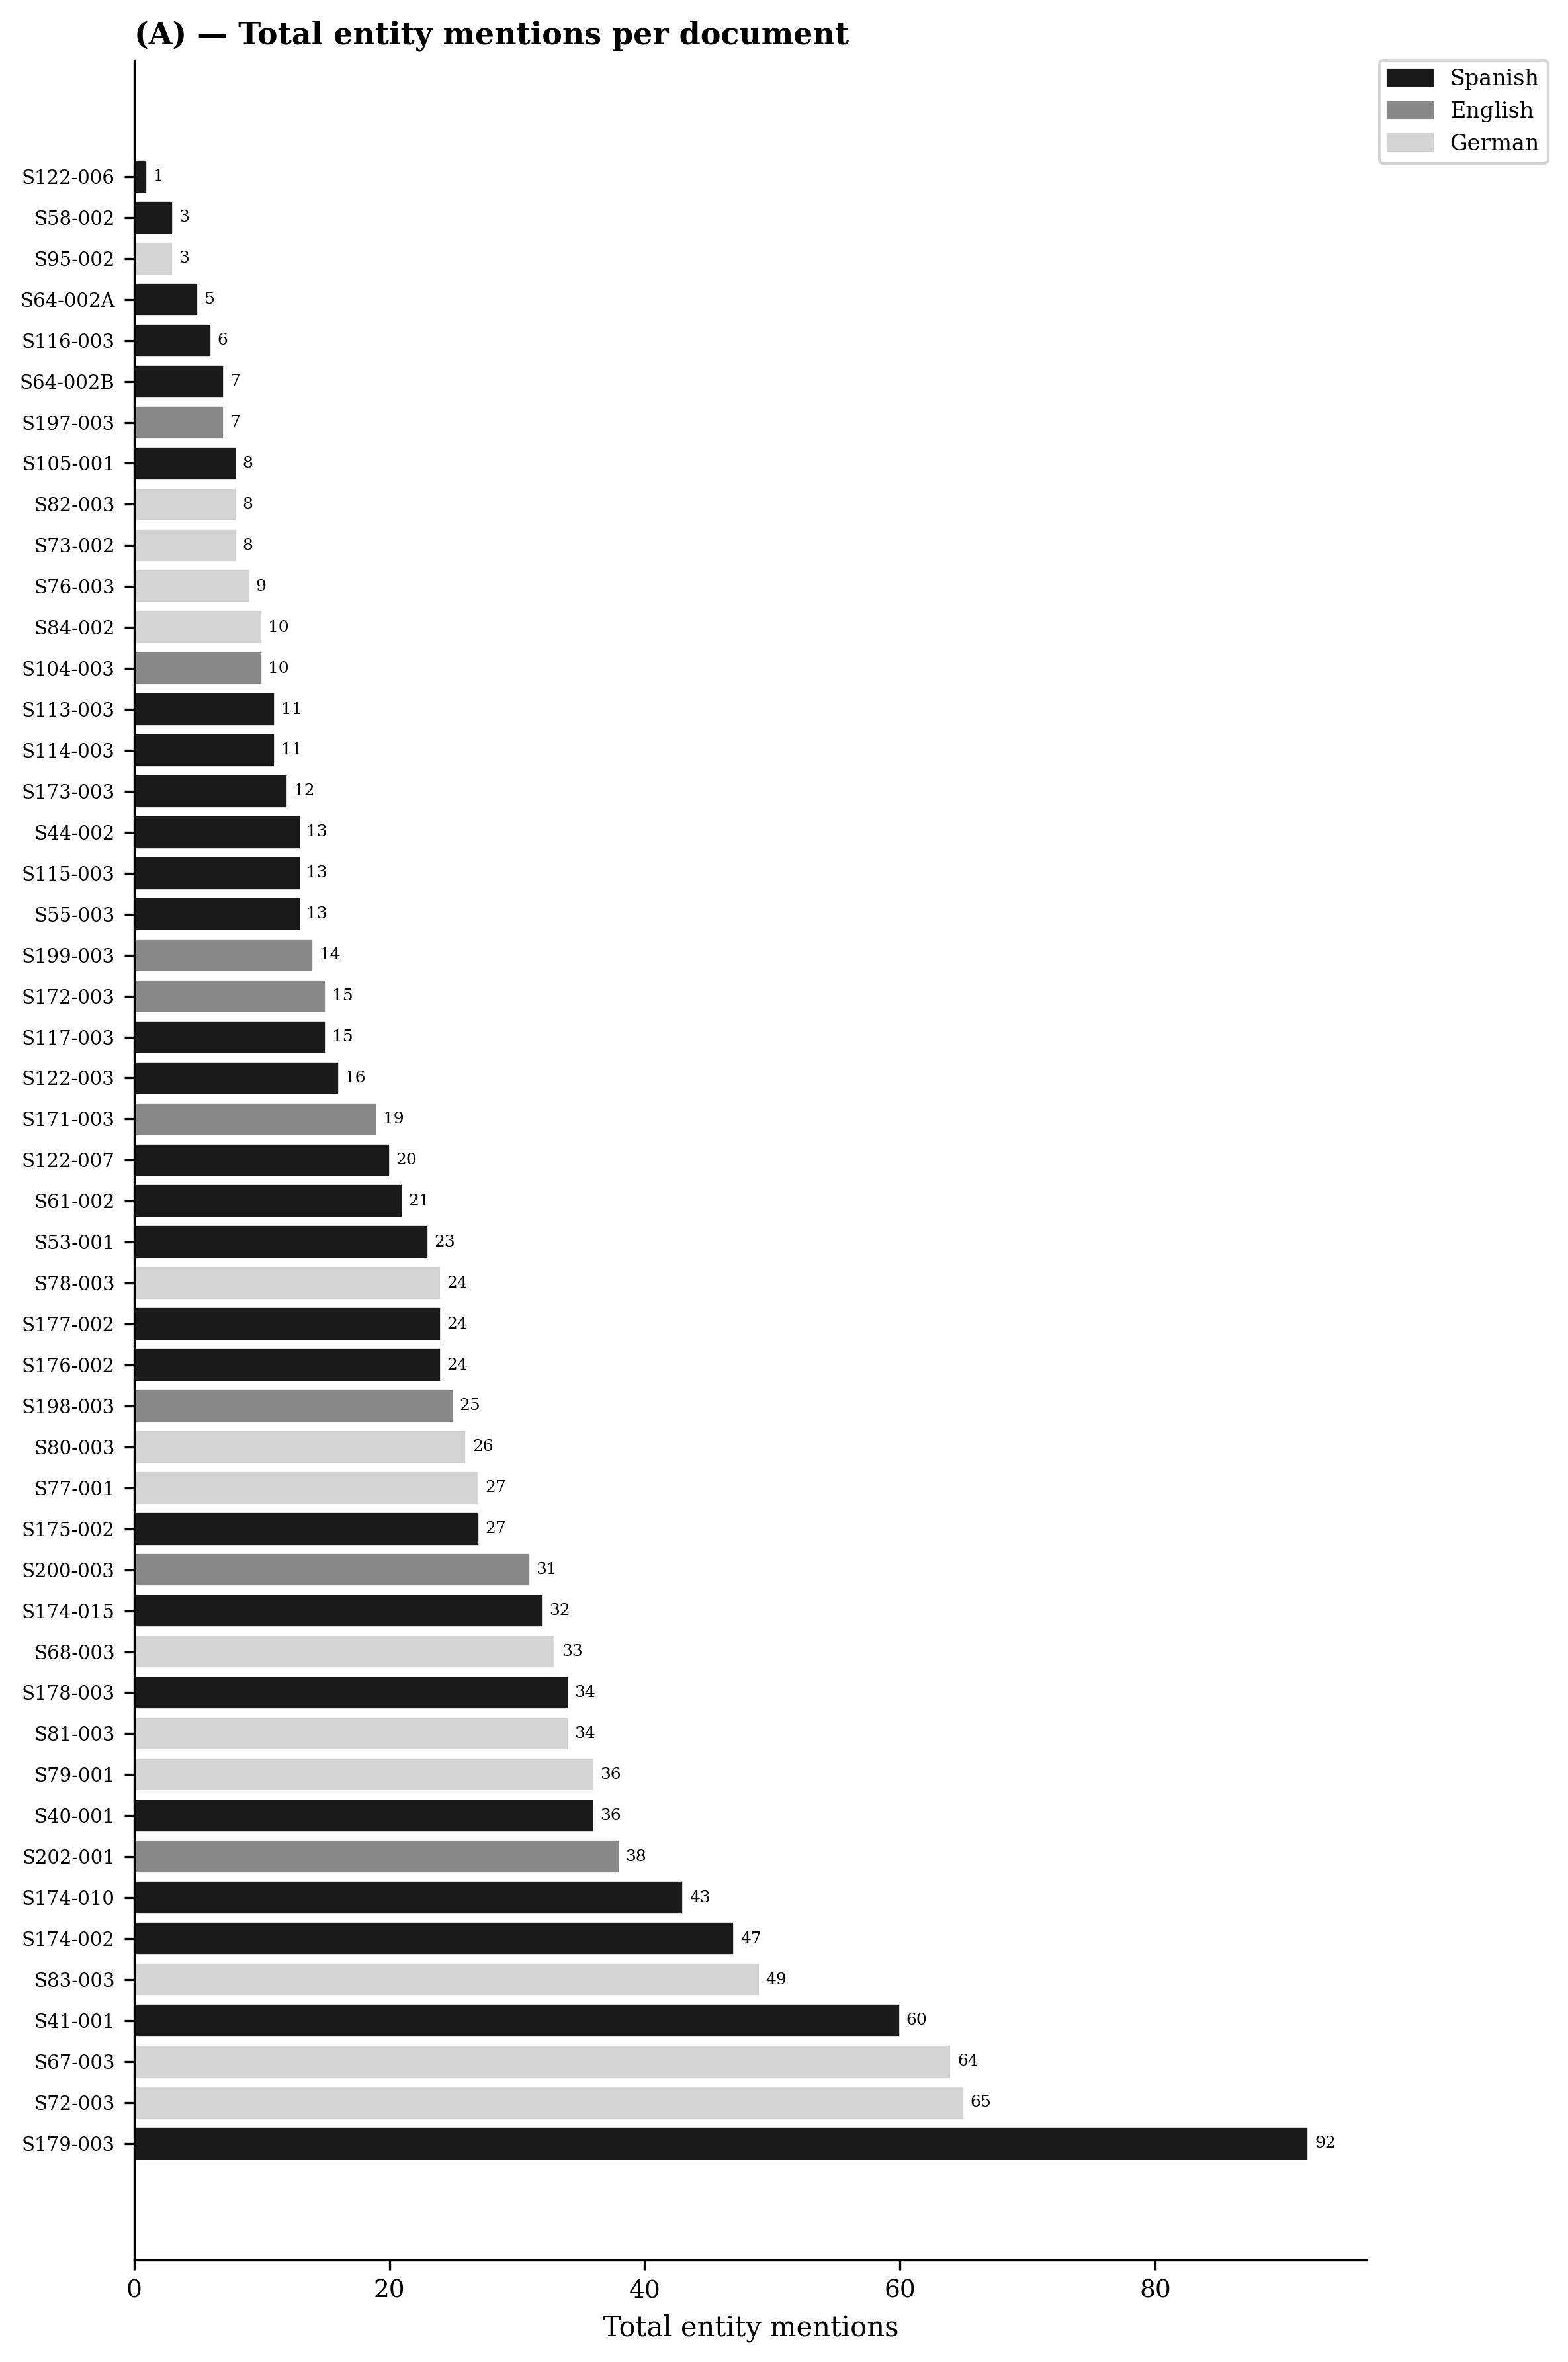

In [6]:
# FIG. 7 — Total entity mentions per document (post-normalization)
fig7, ax_a = plt.subplots(figsize=(8, 12))

bars = ax_a.barh(y, df_fig["total_entities"],
                 color=bar_colors_gray, edgecolor="white", linewidth=0.4)

for bar, val in zip(bars, df_fig["total_entities"]):
    if val > 0:
        ax_a.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
                  str(val), va="center", ha="left", fontsize=6)

ax_a.set_yticks(y)
ax_a.set_yticklabels(labels, fontsize=7)
ax_a.set_xlabel("Total entity mentions")
ax_a.set_title("(A) — Total entity mentions per document", loc="left", fontweight="bold")
ax_a.spines[["top", "right"]].set_visible(False)

# Legend
patches = [mpatches.Patch(color=v, label=k) for k, v in LANG_COLORS_GRAY.items()]
ax_a.legend(handles=patches, fontsize=8,
            loc="upper left",
            bbox_to_anchor=(1.01, 1),
            borderaxespad=0)

plt.tight_layout()
plt.savefig(FIGURES / "fig7_ner_distribution_postnorm_A.png", dpi=300, bbox_inches="tight")
plt.show()

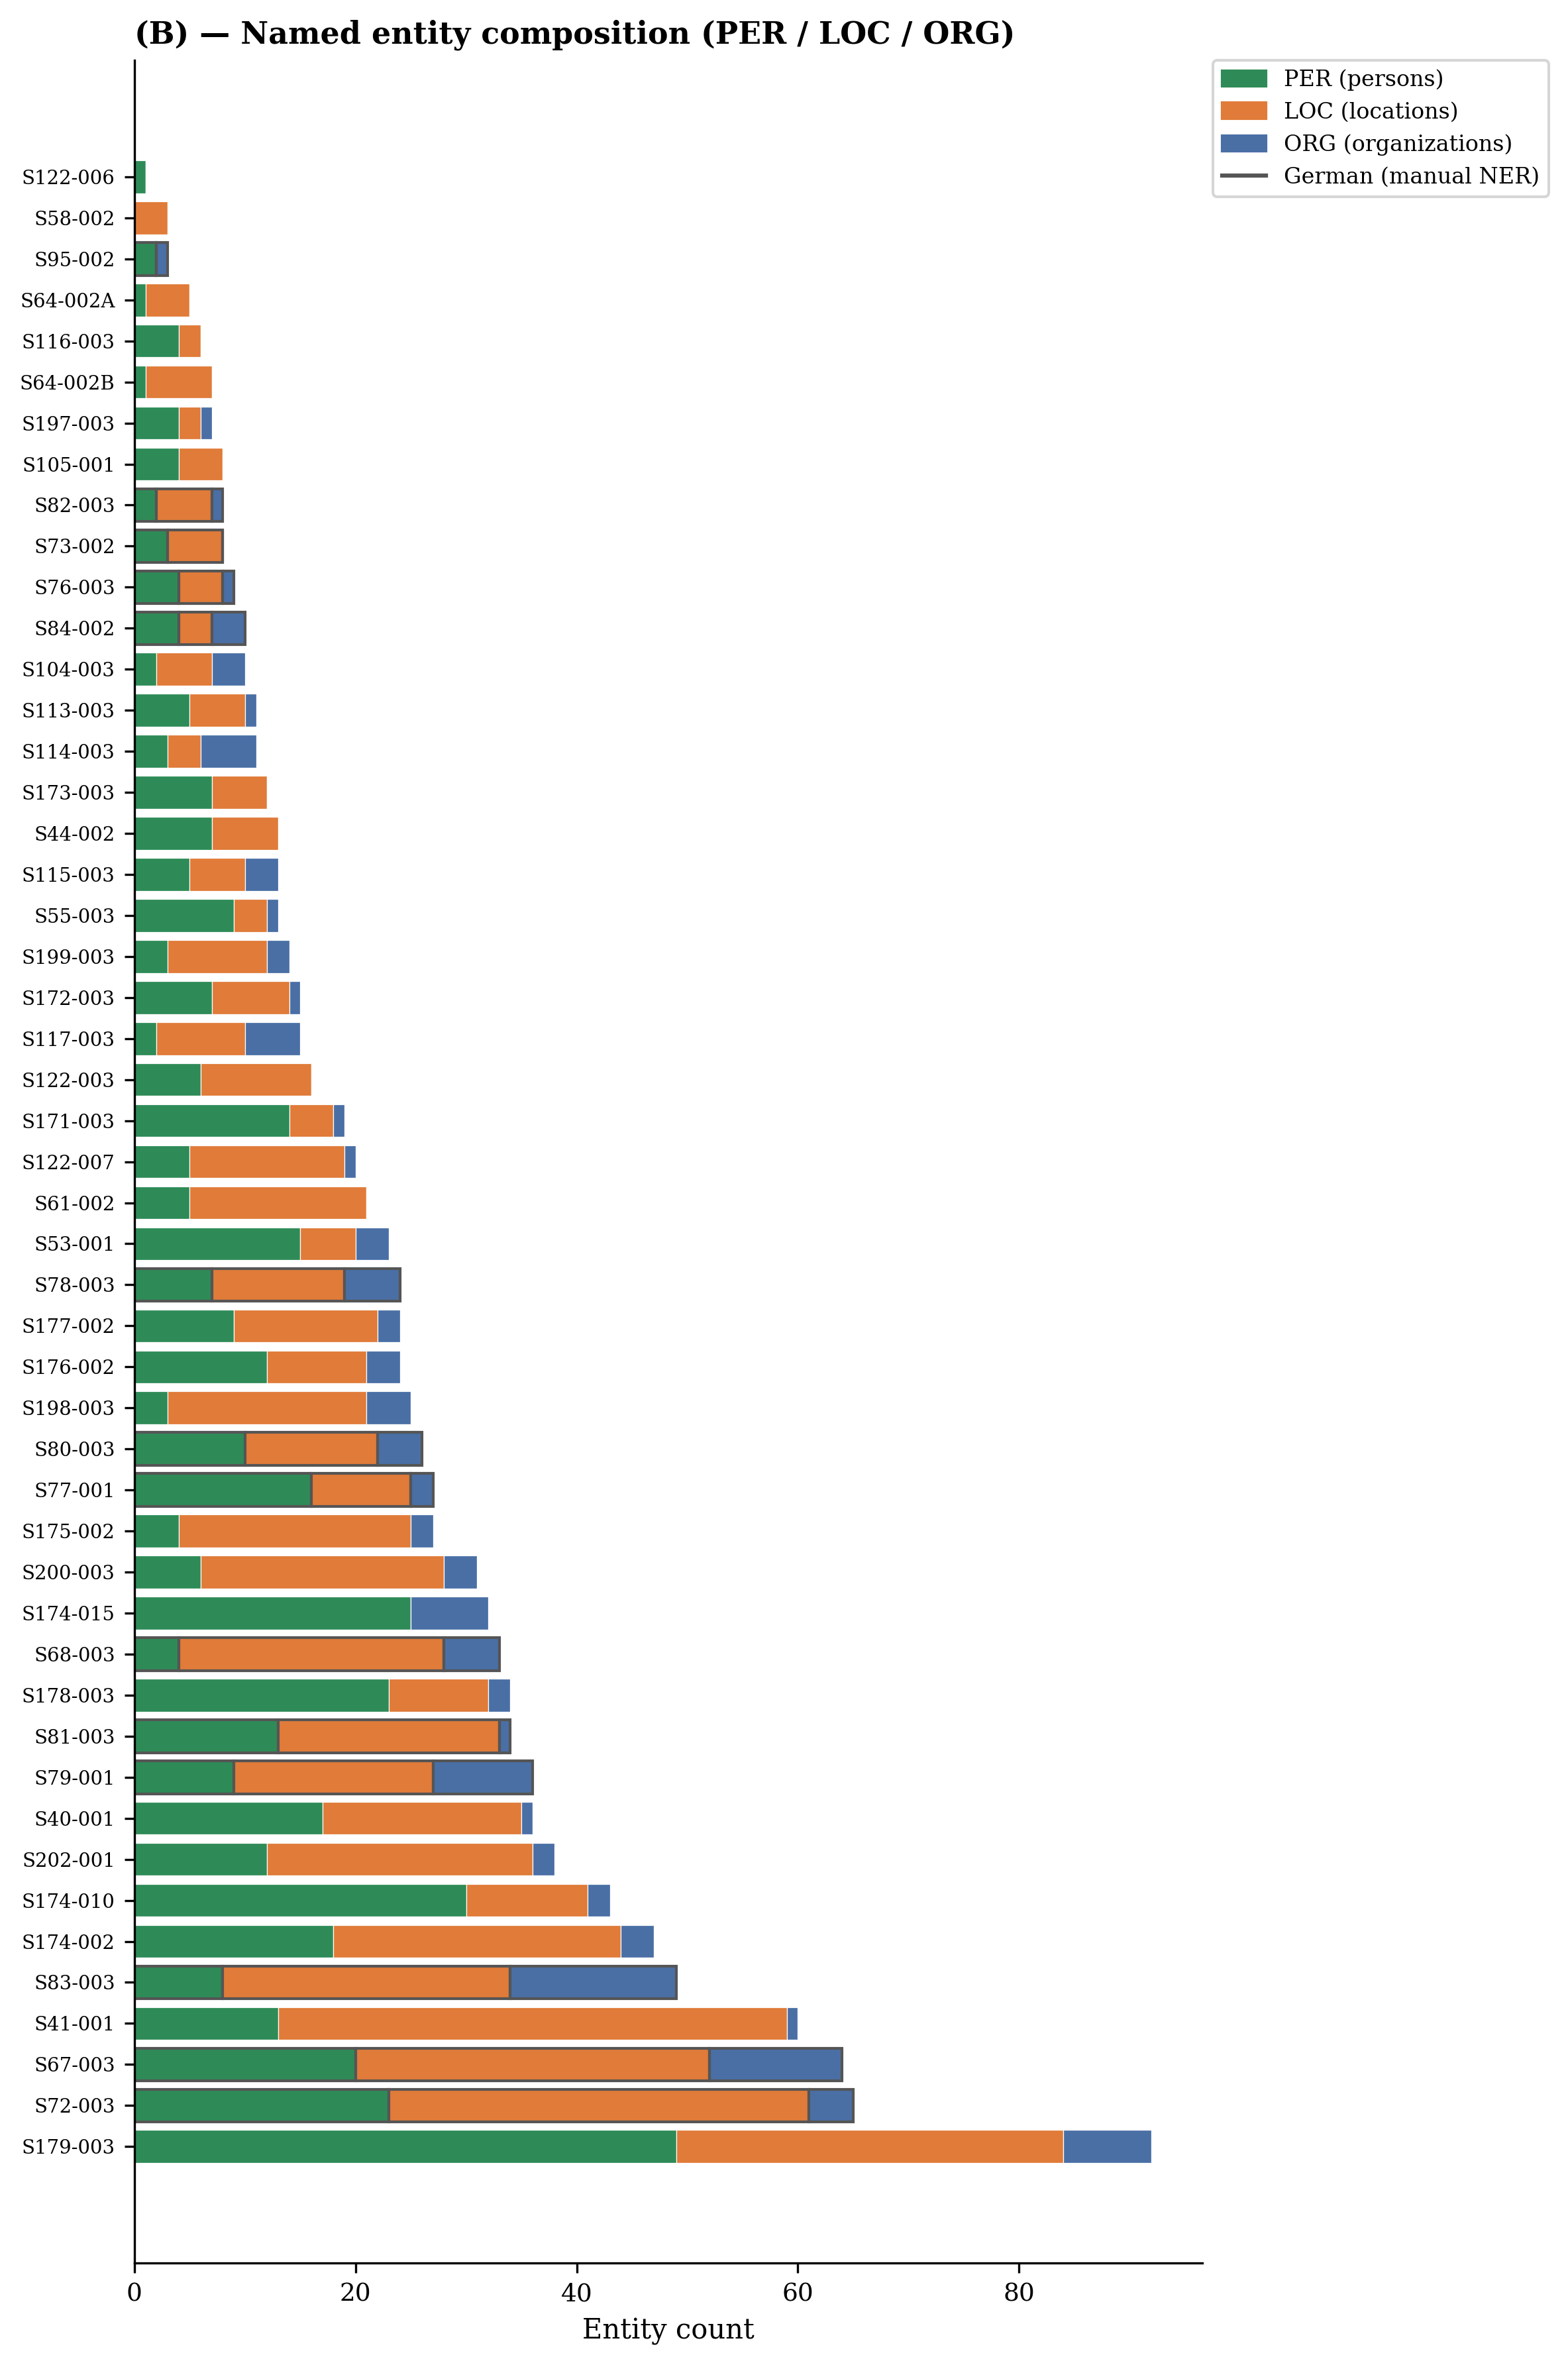

In [7]:
# FIG. 8 — Named entity composition per document (post-normalization)
fig8, ax_b = plt.subplots(figsize=(8, 12))

per_vals = df_fig["PER_count"].values
loc_vals = df_fig["LOC_count"].values
org_vals = df_fig["ORG_count"].values

for i in range(len(y)):
    ax_b.barh(y[i], per_vals[i], color=C_PER,
              edgecolor=edge_colors[i], linewidth=edge_widths[i])
    ax_b.barh(y[i], loc_vals[i], left=per_vals[i], color=C_LOC,
              edgecolor=edge_colors[i], linewidth=edge_widths[i])
    ax_b.barh(y[i], org_vals[i], left=per_vals[i]+loc_vals[i], color=C_ORG,
              edgecolor=edge_colors[i], linewidth=edge_widths[i])

ax_b.set_yticks(y)
ax_b.set_yticklabels(labels, fontsize=7)
ax_b.set_xlabel("Entity count")
ax_b.set_title("(B) — Named entity composition (PER / LOC / ORG)", loc="left", fontweight="bold")
ax_b.spines[["top", "right"]].set_visible(False)

patches = [
    mpatches.Patch(color=C_PER, label="PER (persons)"),
    mpatches.Patch(color=C_LOC, label="LOC (locations)"),
    mpatches.Patch(color=C_ORG, label="ORG (organizations)"),
    mlines.Line2D([], [], color="#555555", linewidth=1.5, label="German (manual NER)"),
]
ax_b.legend(handles=patches, fontsize=8,
            loc="upper left",
            bbox_to_anchor=(1.01, 1),
            borderaxespad=0)

plt.tight_layout()
plt.savefig(FIGURES / "fig8_ner_distribution_postnorm_B.png", dpi=300, bbox_inches="tight")

In [8]:
# FIG. 9 post — Top 15 entities per type
from collections import Counter

def get_top_entities(df, col, n=15):
    all_entities = []
    for entity_list in df[col]:
        for ent in entity_list:
            if ent.strip():
                all_entities.append(ent.strip())
    counter = Counter(all_entities)
    top = counter.most_common(n)
    return pd.DataFrame(top, columns=["entity", "count"])

top_per = get_top_entities(df, "PER", 15)
top_loc = get_top_entities(df, "LOC", 15)
top_org = get_top_entities(df, "ORG", 15)

print("── Top 15 PER ───────────────────────────────────────")
print(top_per.to_string(index=False))
print("\n── Top 15 LOC ───────────────────────────────────────")
print(top_loc.to_string(index=False))
print("\n── Top 15 ORG ───────────────────────────────────────")
print(top_org.to_string(index=False))

── Top 15 PER ───────────────────────────────────────
          entity  count
            Luis     36
          Angela     22
           Strib     20
        Consuelo     19
Rolf Altenburger     15
         Etienne     11
   Ford Bartlett     10
           Bruno      7
   Pepi zu Dohna      6
 Emil Fahrenkamp      6
       Raúl Vial      6
       Bubi Laub      5
   John Dijkstra      5
Betty Schönmeyer      5
         Gonzalo      5

── Top 15 LOC ───────────────────────────────────────
     entity  count
      Chile     40
Switzerland     29
    Germany     18
  Solothurn     18
   Santiago     18
      Paris     17
     London     16
    Austria     16
     Europe     15
     Weimar     14
     Vienna     11
       Lima     10
   New York      9
 Düsseldorf      8
     Warsaw      8

── Top 15 ORG ───────────────────────────────────────
                            entity  count
                             Leica      5
                        Rolleiflex      5
  the Cellulosefabrik 

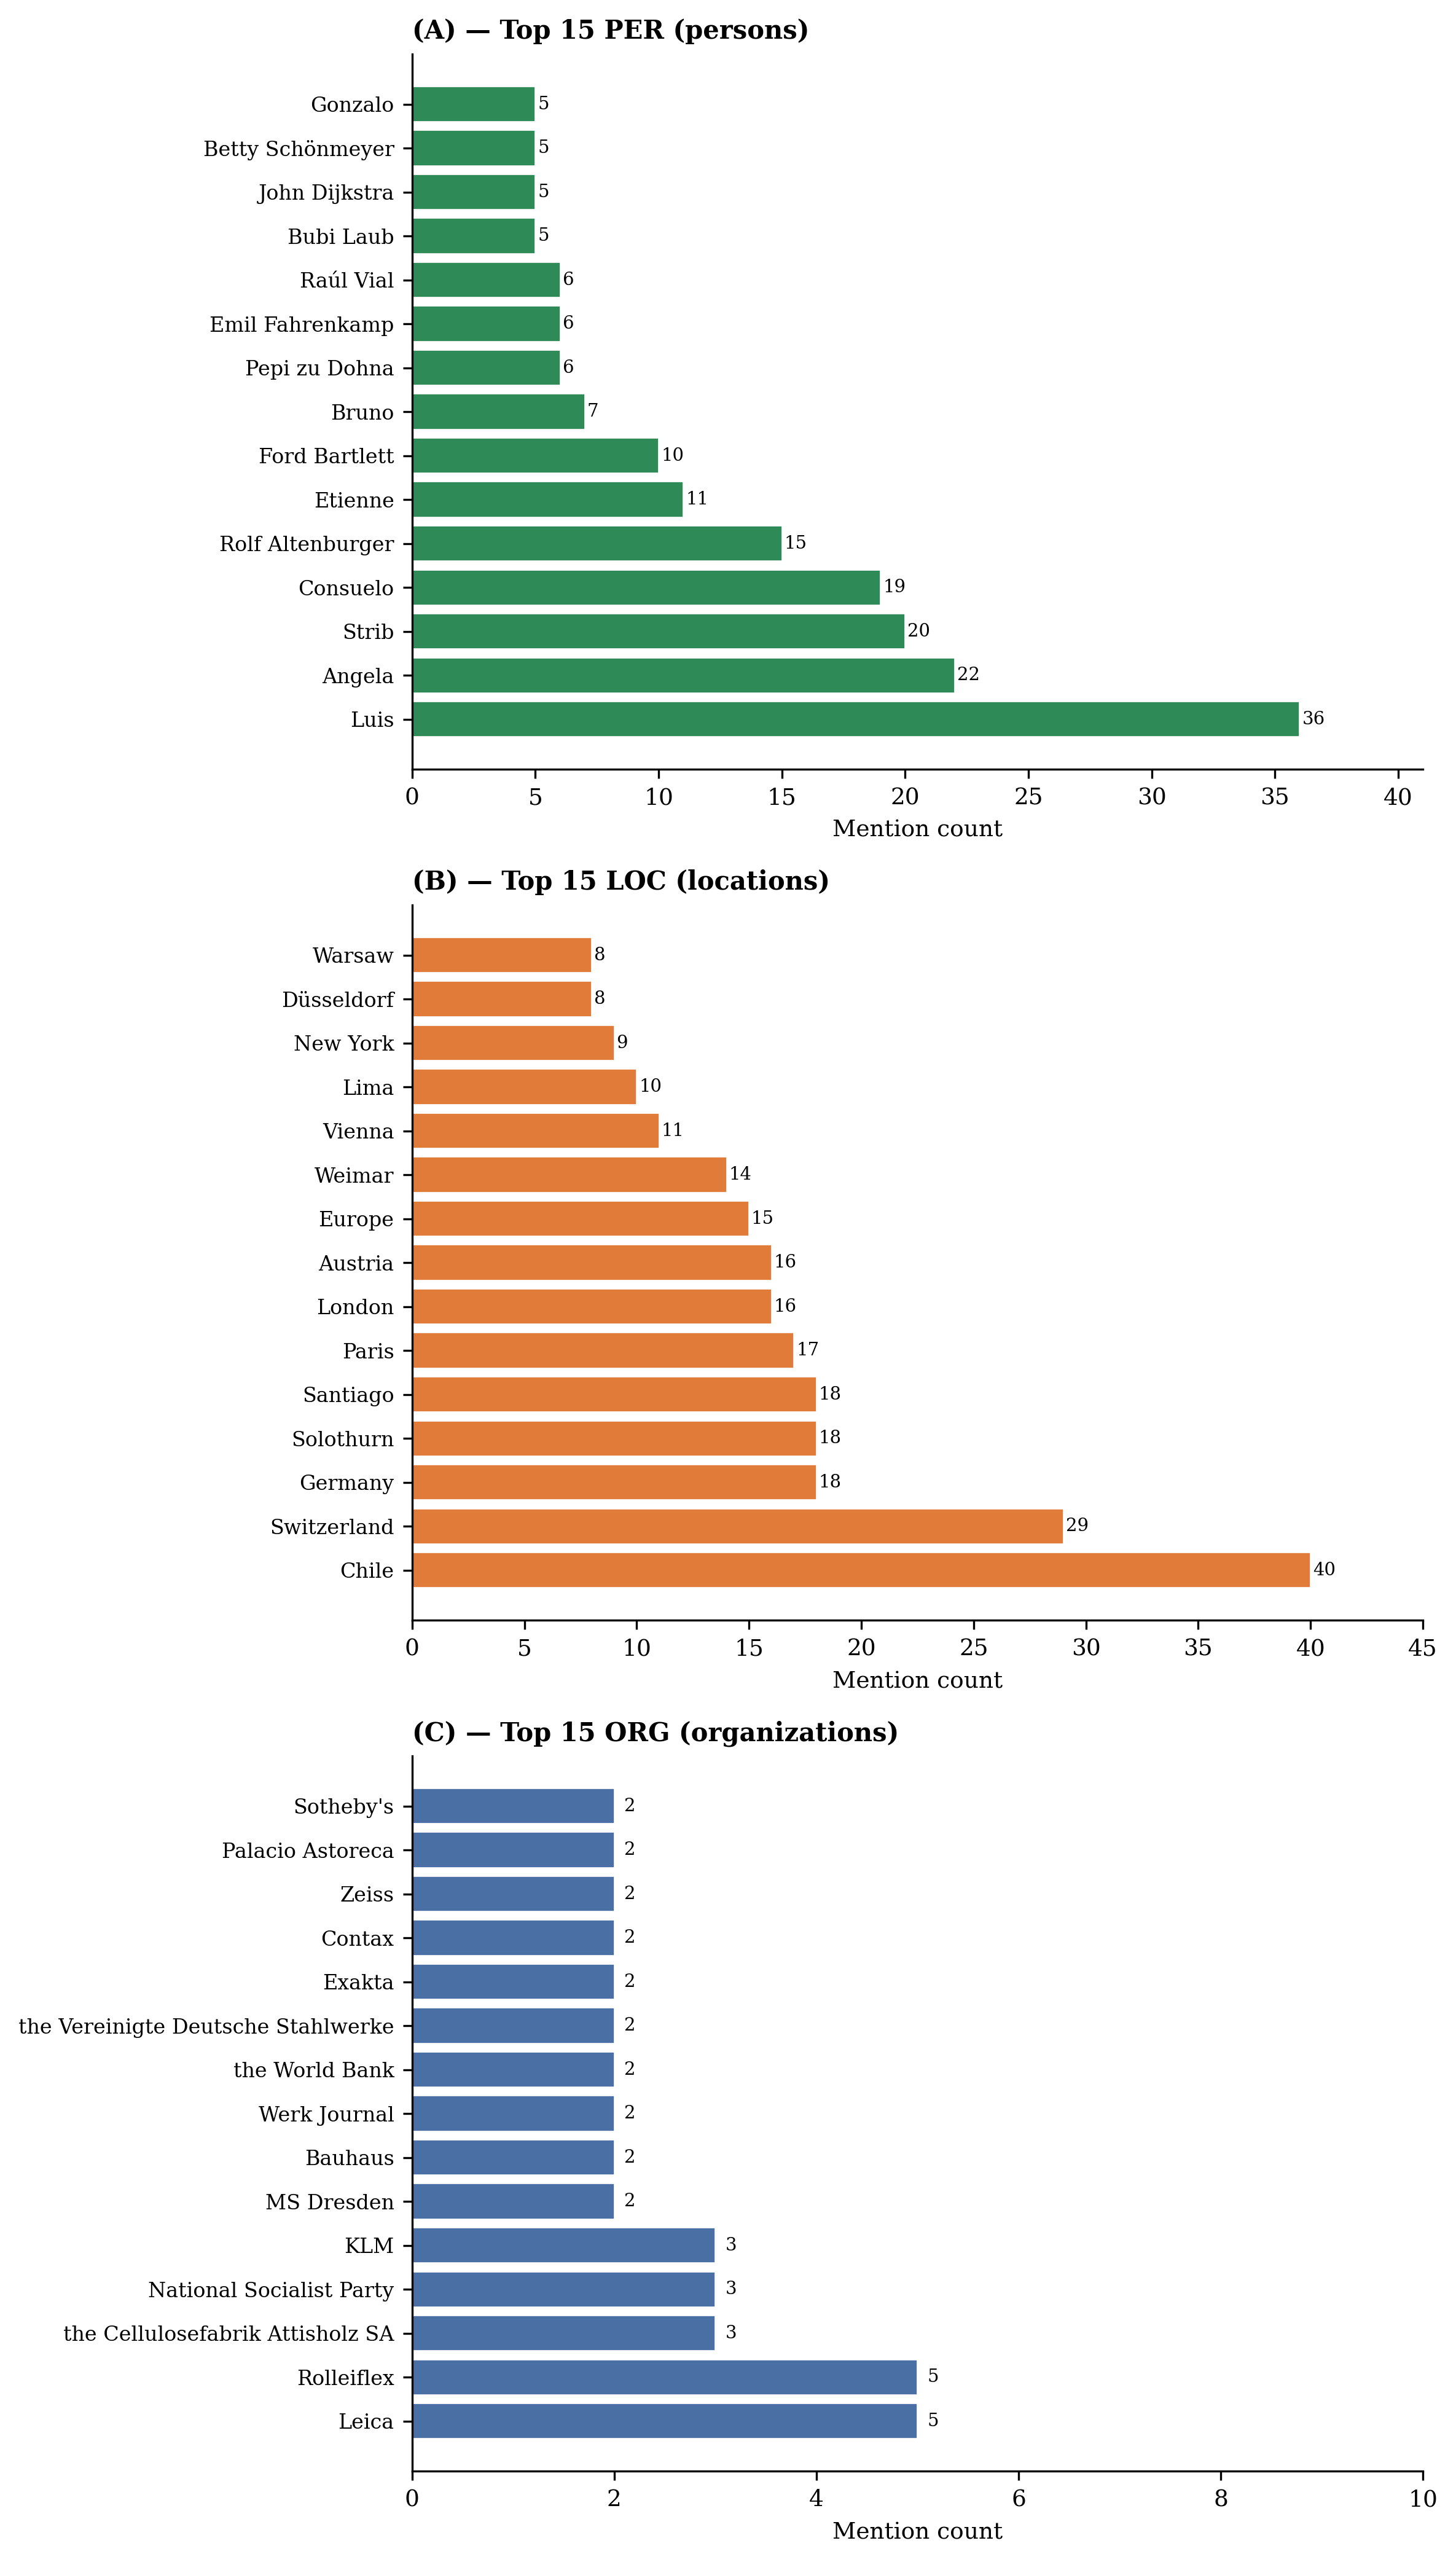

FIG. 9 exported.


In [9]:
# FIG. 9 — Top 15 named entities by type (post-normalization)
# Three panels arranged vertically for letter-size layout

fig9, (ax_per, ax_loc, ax_org) = plt.subplots(3, 1, figsize=(8, 14))

def plot_top_entities(ax, df_top, title, color):
    y_pos = np.arange(len(df_top))
    ax.barh(y_pos, df_top["count"], color=color,
            edgecolor="white", linewidth=0.4)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(df_top["entity"], fontsize=8)
    ax.set_xlabel("Mention count", fontsize=9)
    ax.set_title(title, loc="left", fontweight="bold", fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)
    for bar, val in zip(ax.patches, df_top["count"]):
        ax.text(val + 0.1, bar.get_y() + bar.get_height() / 2,
                str(val), va="center", ha="left", fontsize=7)
    ax.set_xlim(0, df_top["count"].max() + 5)

plot_top_entities(ax_per, top_per, "(A) — Top 15 PER (persons)", C_PER)
plot_top_entities(ax_loc, top_loc, "(B) — Top 15 LOC (locations)", C_LOC)
plot_top_entities(ax_org, top_org, "(C) — Top 15 ORG (organizations)", C_ORG)

plt.tight_layout()
plt.savefig(FIGURES / "fig9_top15_entities_postnorm.png", dpi=300, bbox_inches="tight")
plt.show()
print("FIG. 9 exported.")

In [10]:
# FIG. 9 post — Prominence data
def build_prominence_df(df, col, top_df, entity_type):
    entities = top_df["entity"].tolist()
    rows = []
    for ent in entities:
        total_mentions = 0
        doc_freq       = 0
        for _, row in df.iterrows():
            count = sum(1 for e in row[col] if e.strip() == ent)
            if count > 0:
                total_mentions += count
                doc_freq       += 1
        rows.append({
            "entity"        : ent,
            "total_mentions": total_mentions,
            "doc_frequency" : doc_freq,
            "type"          : entity_type
        })
    return pd.DataFrame(rows)

prom_per = build_prominence_df(df, "PER", top_per, "PER")
prom_loc = build_prominence_df(df, "LOC", top_loc, "LOC")
prom_org = build_prominence_df(df, "ORG", top_org, "ORG")

df_prominence = pd.concat([prom_per, prom_loc, prom_org], ignore_index=True)

# Top 15 global by total mentions
df_top15_global = (df_prominence
                   .sort_values("total_mentions", ascending=False)
                   .head(15)
                   .reset_index(drop=True))

print("── Top 15 global ────────────────────────────────────")
print(df_top15_global[["entity", "total_mentions", "doc_frequency", "type"]]
      .to_string(index=False))

── Top 15 global ────────────────────────────────────
          entity  total_mentions  doc_frequency type
           Chile              40             20  LOC
            Luis              36             31  PER
     Switzerland              29             12  LOC
          Angela              22             16  PER
           Strib              20              6  PER
        Consuelo              19              7  PER
       Solothurn              18             10  LOC
         Germany              18             11  LOC
        Santiago              18             14  LOC
           Paris              17             10  LOC
         Austria              16              8  LOC
          London              16              6  LOC
Rolf Altenburger              15             10  PER
          Europe              15              7  LOC
          Weimar              14             12  LOC


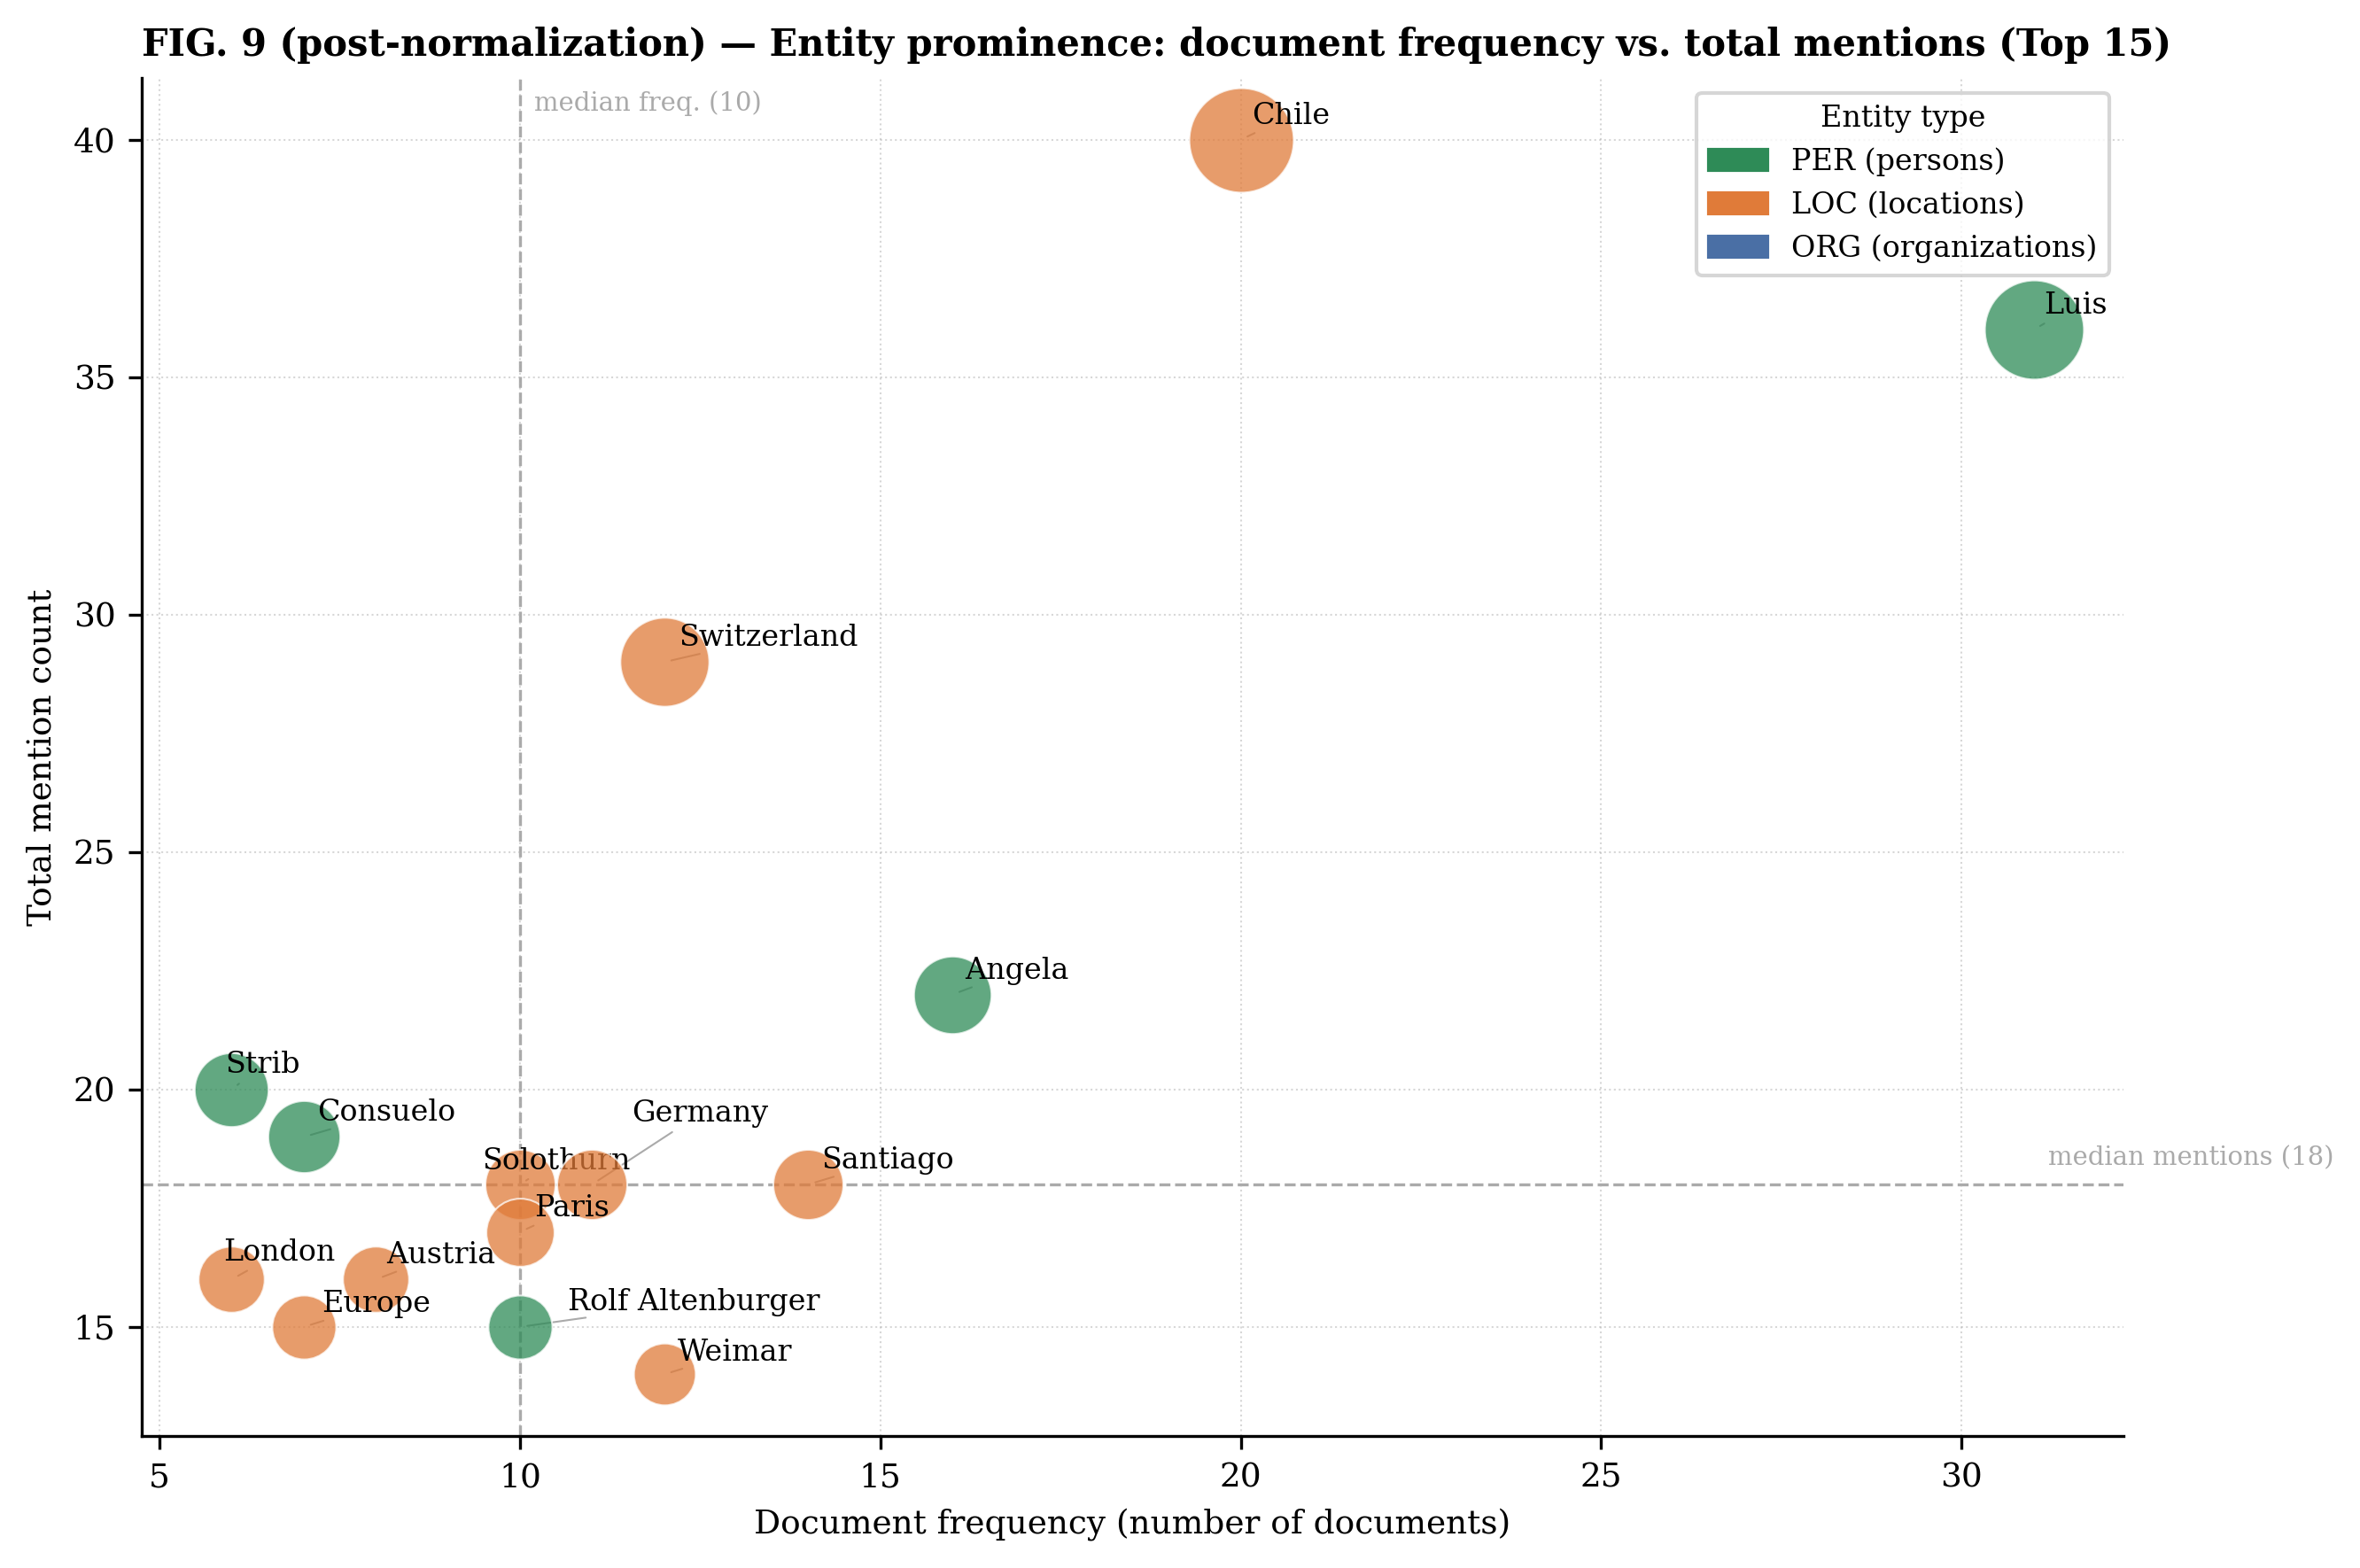

FIG. 10 post exported.


In [11]:
# FIG. 10 post — Bubble chart - ENTITY PROMINENCE
fig9, ax9 = plt.subplots(figsize=(9, 6))

TYPE_COLORS = {"PER": C_PER, "LOC": C_LOC, "ORG": C_ORG}

texts = []
for _, row in df_top15_global.iterrows():
    ax9.scatter(
        row["doc_frequency"],
        row["total_mentions"],
        s=row["total_mentions"] * 20,
        color=TYPE_COLORS[row["type"]],
        alpha=0.75,
        edgecolors="white",
        linewidths=0.5,
        zorder=3
    )
    texts.append(ax9.text(
        row["doc_frequency"],
        row["total_mentions"],
        row["entity"],
        fontsize=8
    ))

adjust_text(
    texts,
    ax=ax9,
    arrowprops=dict(arrowstyle="-", color="#aaaaaa", lw=0.5),
    expand=(1.3, 1.5),
    force_text=(0.5, 0.8)
)

# Reference lines
med_freq = df_top15_global["doc_frequency"].median()
med_ment = df_top15_global["total_mentions"].median()
ax9.axvline(med_freq, color="#aaaaaa", linestyle="--", linewidth=0.8, zorder=1)
ax9.axhline(med_ment, color="#aaaaaa", linestyle="--", linewidth=0.8, zorder=1)
ax9.text(med_freq + 0.2, df_top15_global["total_mentions"].max() + 0.5,
         f"median freq. ({med_freq:.0f})", fontsize=7, color="#aaaaaa",
         ha="left", va="bottom")
ax9.text(df_top15_global["doc_frequency"].max() + 0.2, med_ment + 0.3,
         f"median mentions ({med_ment:.0f})", fontsize=7, color="#aaaaaa",
         ha="left", va="bottom")

# Legend
type_handles = [
    mpatches.Patch(color=C_PER, label="PER (persons)"),
    mpatches.Patch(color=C_LOC, label="LOC (locations)"),
    mpatches.Patch(color=C_ORG, label="ORG (organizations)"),
]
ax9.legend(handles=type_handles, fontsize=8,
           title="Entity type", title_fontsize=8)

ax9.set_xlabel("Document frequency (number of documents)", fontsize=9)
ax9.set_ylabel("Total mention count", fontsize=9)
ax9.set_title("FIG. 9 (post-normalization) — Entity prominence: document frequency vs. total mentions (Top 15)",
              loc="left", fontweight="bold", fontsize=10)
ax9.spines[["top", "right"]].set_visible(False)
ax9.grid(axis="both", linestyle=":", linewidth=0.5, alpha=0.5, zorder=0)


plt.tight_layout()
plt.savefig(FIGURES / "fig10_post_bubble_prominence.png", dpi=300, bbox_inches="tight")
plt.show()

print("FIG. 10 post exported.")

In [12]:
# Load normalized CSV with dates
DATA_FILE_DATES = DATA_PROC / "NER_normalized_clean_dates.csv"

for enc in ["utf-8-sig", "utf-8", "latin-1"]:
    try:
        df_dates = pd.read_csv(DATA_FILE_DATES, encoding=enc, sep=";",
                               quotechar='"', quoting=0, engine="python")
        print(f"Encoding detected : {enc}")
        break
    except Exception as e:
        print(f"  Failed {enc}: {e}")

df_dates = df_dates.dropna(how="all")
df_dates = df_dates[df_dates["doc_id"].notna()].reset_index(drop=True)

# Parse date → year 
df_dates["year"] = pd.to_datetime(df_dates["Date"], 
                                   format="%d-%m-%Y", 
                                   errors="coerce").dt.year

# Parse entity lists
for col, target in [("PER_normalized", "PER"), 
                    ("LOC_normalized", "LOC"), 
                    ("ORG_normalized", "ORG")]:
    df_dates[target] = df_dates[col].apply(parse_entities)

# Inspection 
print(f"\n── Shape : {df_dates.shape[0]} documents × {df_dates.shape[1]} columns")
print(f"\n── Year distribution ───────────────────────────────")
print(df_dates["year"].value_counts().sort_index().to_string())
print(f"\n── Null years : {df_dates['year'].isna().sum()}")

Encoding detected : utf-8-sig

── Shape : 49 documents × 12 columns

── Year distribution ───────────────────────────────
year
1935     4
1936    13
1937     5
1941     1
1942     3
1943     1
1961     8
1968     1
1969     1
1972     1
1989     1
1990     1
1991     4
1992     3
1993     1
2006     1

── Null years : 0


In [13]:
# ── Timeline data preparation ─────────────────────────────────────────────────
# For each year and entity type: aggregate total mentions and unique entities

def build_timeline_df(df_dates, col, top_df, entity_type):
    """
    For each year: sum mentions of Top 15 entities.
    Returns long-format df: year, entity, total_mentions, type
    """
    entities = top_df["entity"].tolist()
    rows = []
    for year, group in df_dates.groupby("year"):
        for ent in entities:
            total = sum(
                sum(1 for e in row[col] if e.strip() == ent)
                for _, row in group.iterrows()
            )
            if total > 0:
                rows.append({
                    "year"          : year,
                    "entity"        : ent,
                    "total_mentions": total,
                    "type"          : entity_type
                })
    return pd.DataFrame(rows)

tl_per = build_timeline_df(df_dates, "PER", top_per, "PER")
tl_loc = build_timeline_df(df_dates, "LOC", top_loc, "LOC")
tl_org = build_timeline_df(df_dates, "ORG", top_org, "ORG")

print(f"── Timeline PER shape : {tl_per.shape}")
print(f"── Timeline LOC shape : {tl_loc.shape}")
print(f"── Timeline ORG shape : {tl_org.shape}")

print(f"\n── PER sample ───────────────────────────────────────")
print(tl_per.head(10).to_string(index=False))

── Timeline PER shape : (52, 4)
── Timeline LOC shape : (70, 4)
── Timeline ORG shape : (19, 4)

── PER sample ───────────────────────────────────────
 year           entity  total_mentions type
 1935             Luis               3  PER
 1935          Gonzalo               3  PER
 1936             Luis               5  PER
 1936 Rolf Altenburger               1  PER
 1936    Pepi zu Dohna               2  PER
 1936  Emil Fahrenkamp               5  PER
 1936        Bubi Laub               3  PER
 1936          Gonzalo               1  PER
 1937             Luis               6  PER
 1937 Rolf Altenburger               3  PER


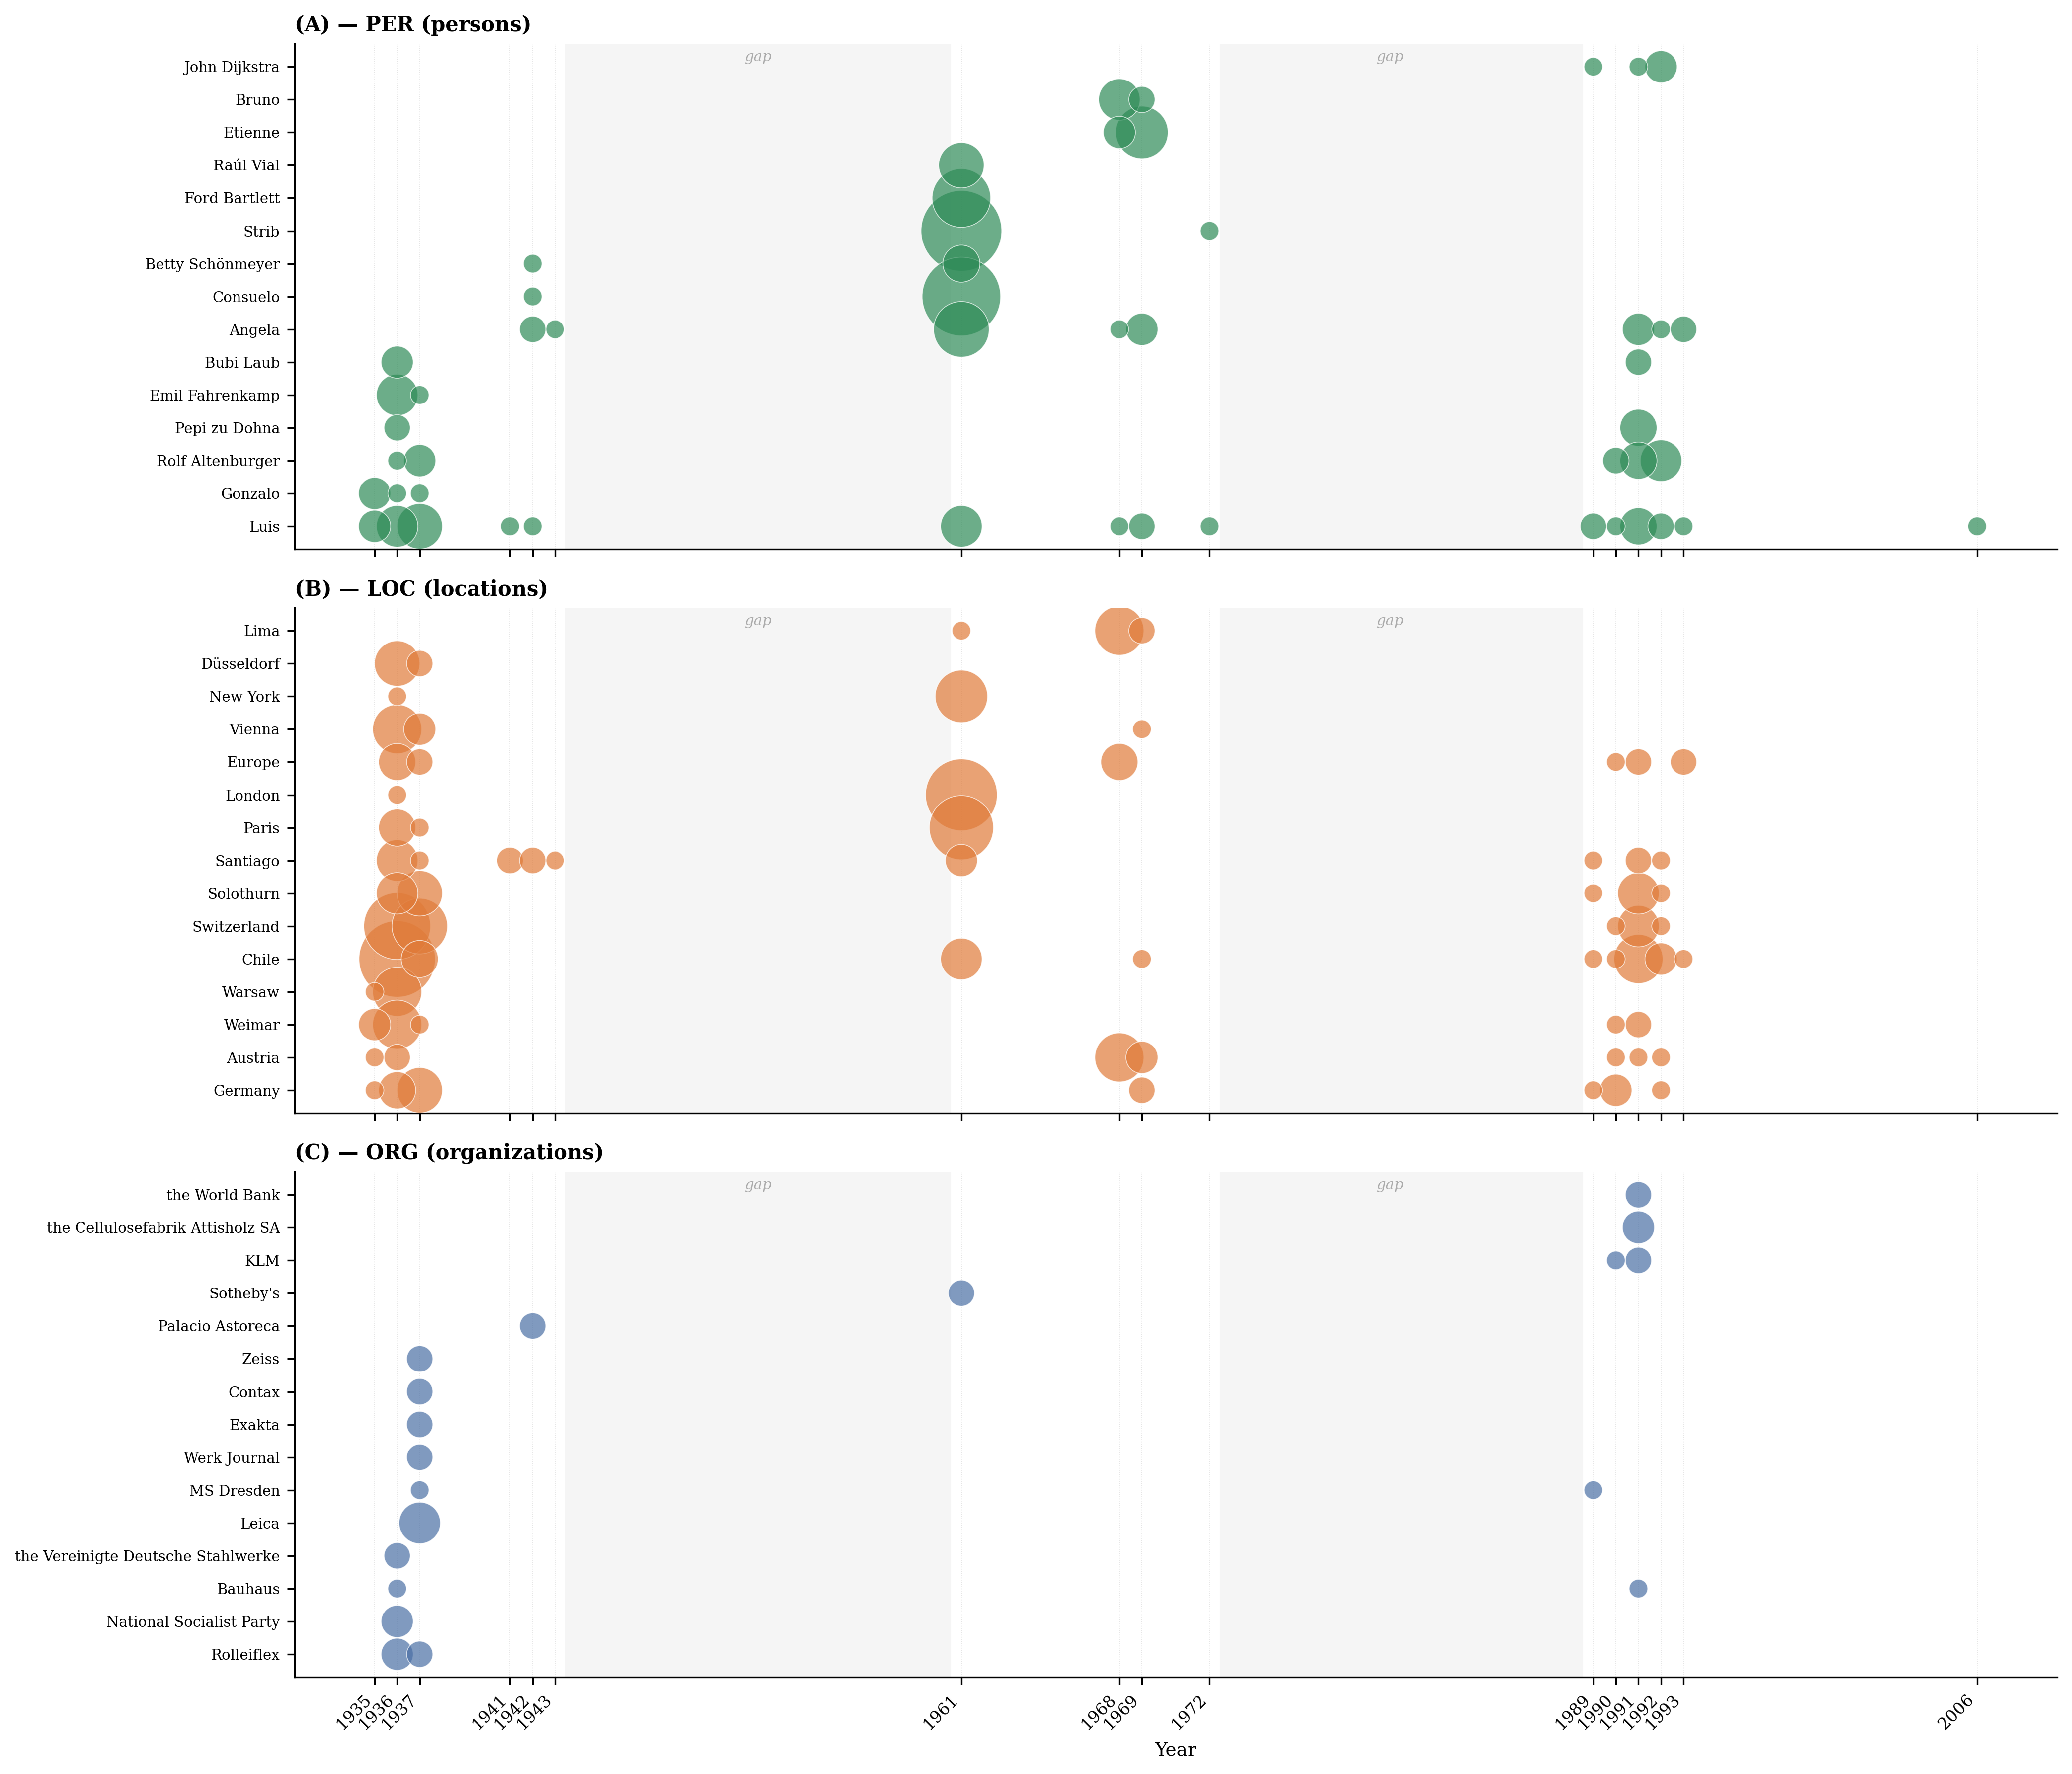

FIG. 11 Timeline exported.


In [14]:
# FIG. Timeline — Entity mentions over time (Top 15 per type)
fig_tl, (ax_per, ax_loc, ax_org) = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

all_years = sorted(df_dates["year"].unique())

def plot_timeline_panel(ax, tl_df, title, color):
    # For each year, get all entities and their mentions
    # Sort so larger bubbles are drawn first (behind smaller ones)
    tl_sorted = tl_df.sort_values("total_mentions", ascending=False)
    
    # Assign y positions per entity (consistent across years)
    entities  = tl_df["entity"].unique().tolist()
    ent_pos   = {e: i for i, e in enumerate(entities)}
    
    ax.scatter(
        tl_sorted["year"],
        tl_sorted["entity"].map(ent_pos),
        s=tl_sorted["total_mentions"] * 80,
        color=color,
        alpha=0.7,
        edgecolors="white",
        linewidths=0.4,
        zorder=3
    )

    # Y axis labels
    ax.set_yticks(range(len(entities)))
    ax.set_yticklabels(entities, fontsize=7)
    ax.set_title(title, loc="left", fontweight="bold", fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="x", linestyle=":", linewidth=0.4, alpha=0.4, zorder=0)

    # Gap indicators
    ax.axvspan(1943.5, 1960.5, color="#f5f5f5", zorder=0)
    ax.text(1952, len(entities) - 0.5, "gap",
            ha="center", va="top", fontsize=7, color="#aaaaaa", style="italic")

    ax.axvspan(1972.5, 1988.5, color="#f5f5f5", zorder=0)
    ax.text(1980, len(entities) - 0.5, "gap",
            ha="center", va="top", fontsize=7, color="#aaaaaa", style="italic")

plot_timeline_panel(ax_per, tl_per, "(A) — PER (persons)",       C_PER)
plot_timeline_panel(ax_loc, tl_loc, "(B) — LOC (locations)",     C_LOC)
plot_timeline_panel(ax_org, tl_org, "(C) — ORG (organizations)", C_ORG)

# X axis
ax_org.set_xlabel("Year", fontsize=9)
ax_org.set_xticks(all_years)
ax_org.set_xticklabels(all_years, rotation=45, ha="right", fontsize=8)


plt.tight_layout()
plt.savefig(FIGURES / "fig_11_timeline.png", dpi=300, bbox_inches="tight")
plt.show()

print("FIG. 11 Timeline exported.")

In [15]:
# ── FIG. 6 — Pre vs. post normalization comparison 
# Pre-normalization values from Fase2_NER.ipynb (n=50)
# Post-normalization values from this notebook (n=49)

comparison = pd.DataFrame({
    "type": ["PER", "LOC", "ORG"],
    "pre_mentions" : [391, 363, 168],
    "post_mentions": [456, 586, 130],
    "pre_unique"   : [302, 282, 151],
    "post_unique"  : [344, 425, 112],
})

print(comparison.to_string(index=False))

type  pre_mentions  post_mentions  pre_unique  post_unique
 PER           391            456         302          344
 LOC           363            586         282          425
 ORG           168            130         151          112


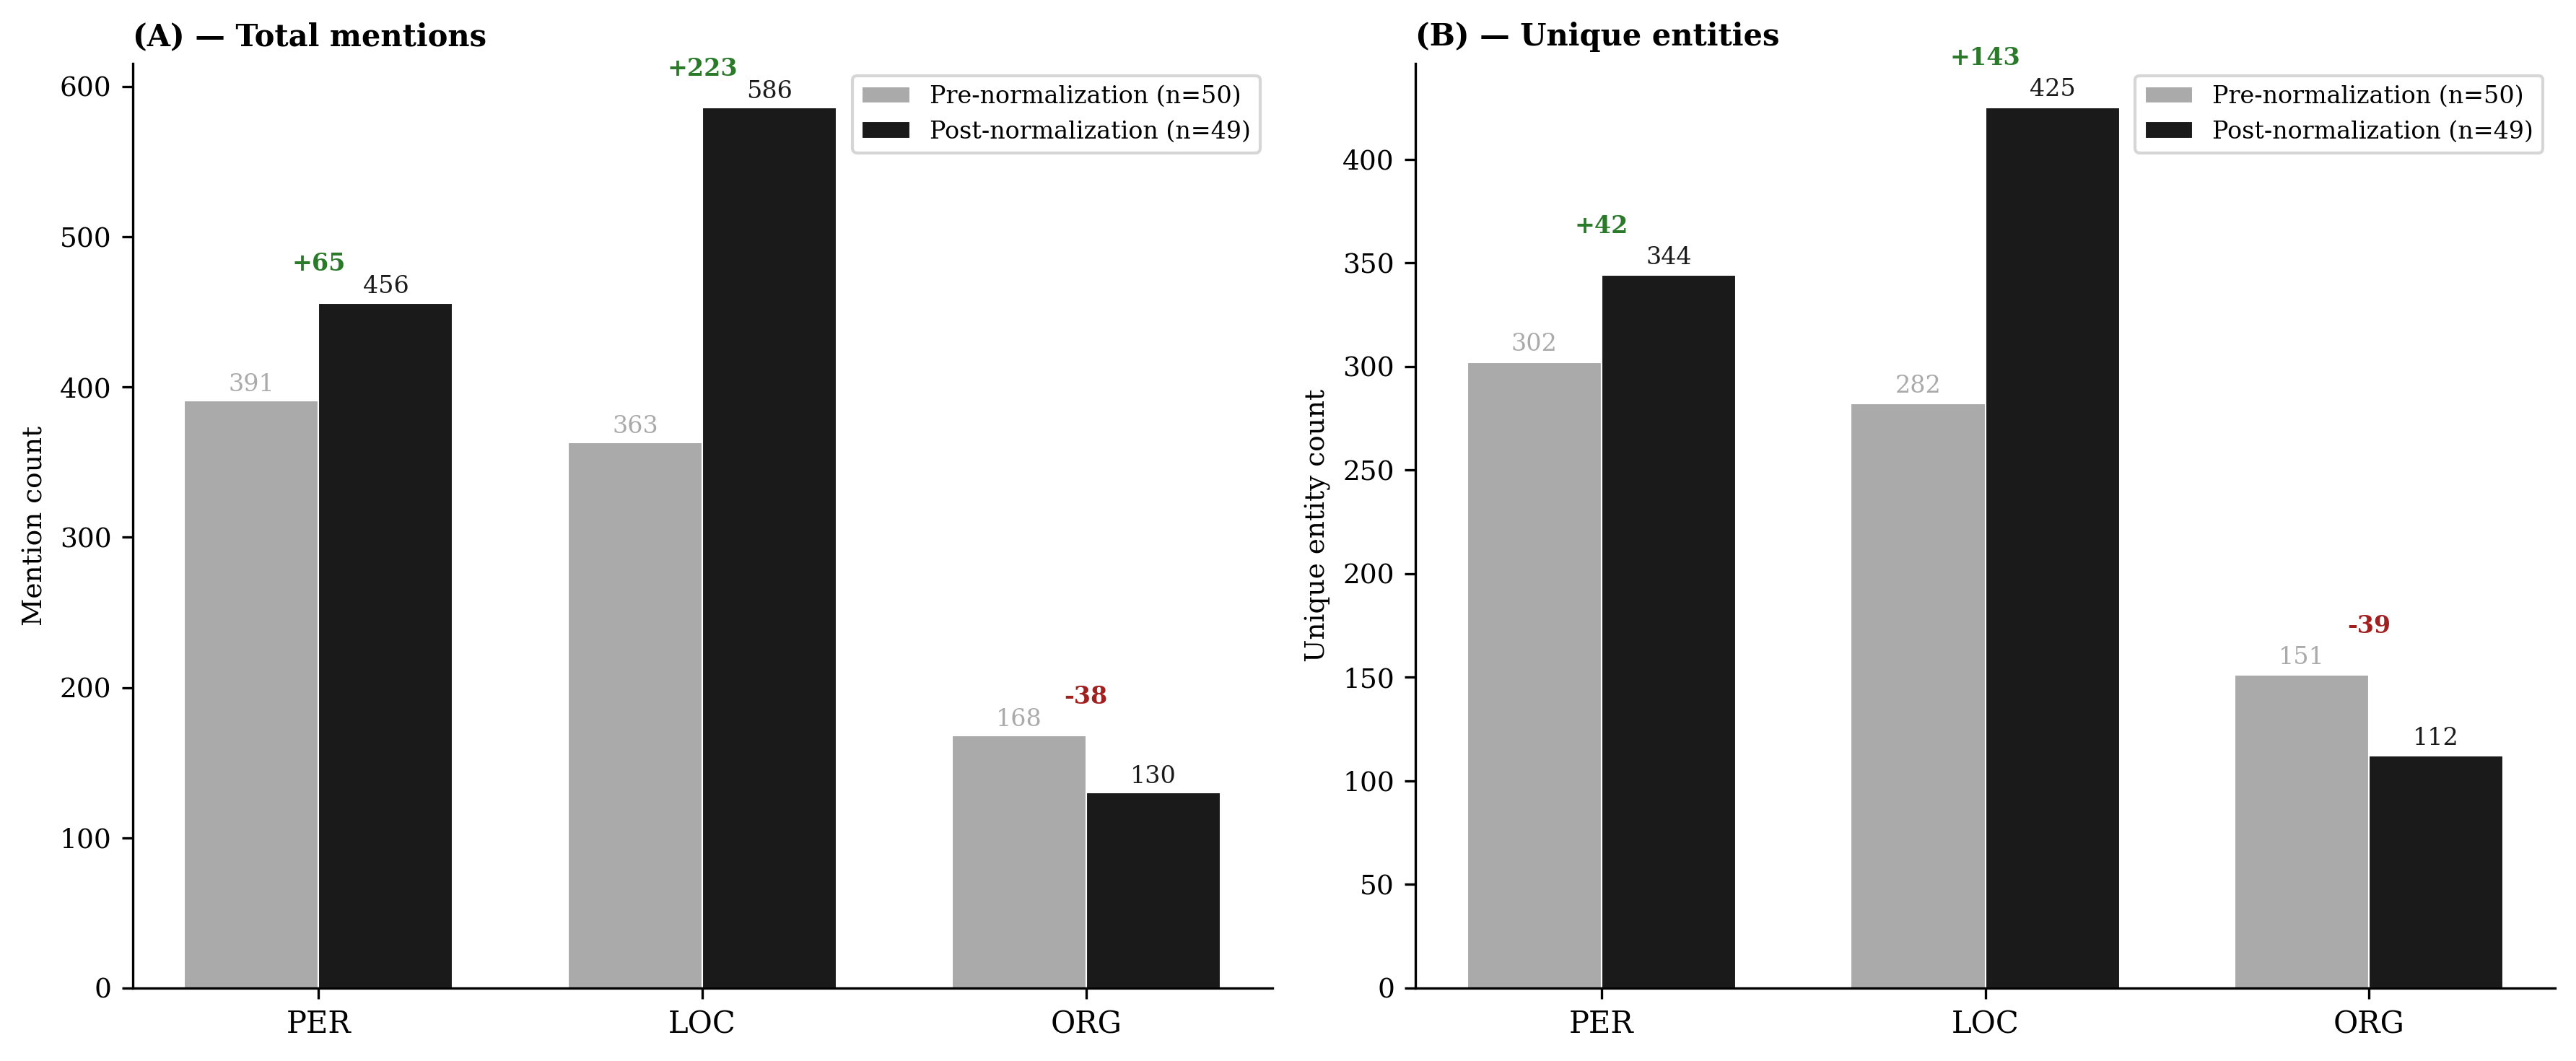

FIG. 6 exported.


In [16]:
# ── FIG. 11 — Pre vs. post normalization comparison ───────────────────────────
fig11, (ax_ment, ax_uniq) = plt.subplots(1, 2, figsize=(12, 5))

x      = np.arange(len(comparison["type"]))
width  = 0.35

# Colors
COLOR_PRE  = "#aaaaaa"   # light gray → pre
COLOR_POST = "#1a1a1a"   # dark gray  → post

def plot_comparison(ax, col_pre, col_post, title, ylabel):
    bars_pre  = ax.bar(x - width/2, comparison[col_pre],  width,
                       color=COLOR_PRE,  edgecolor="white", linewidth=0.5,
                       label="Pre-normalization (n=50)")
    bars_post = ax.bar(x + width/2, comparison[col_post], width,
                       color=COLOR_POST, edgecolor="white", linewidth=0.5,
                       label="Post-normalization (n=49)")

    # Annotate bars
    for bar in bars_pre:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3,
                str(int(bar.get_height())),
                ha="center", va="bottom", fontsize=8, color=COLOR_PRE)
    for bar in bars_post:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3,
                str(int(bar.get_height())),
                ha="center", va="bottom", fontsize=8, color=COLOR_POST)

    # Delta annotations
    for i, (pre, post) in enumerate(zip(comparison[col_pre], comparison[col_post])):
        delta = post - pre
        sign  = "+" if delta >= 0 else ""
        color = "#2a7a2a" if delta >= 0 else "#a02020"
        ax.text(i, max(pre, post) + 18,
                f"{sign}{delta}", ha="center", va="bottom",
                fontsize=8, color=color, fontweight="bold")

    ax.set_xticks(x)
    ax.set_xticklabels(comparison["type"], fontsize=10)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(title, loc="left", fontweight="bold", fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(fontsize=8)

plot_comparison(ax_ment, "pre_mentions",  "post_mentions",
                "(A) — Total mentions",  "Mention count")
plot_comparison(ax_uniq, "pre_unique",    "post_unique",
                "(B) — Unique entities", "Unique entity count")


plt.tight_layout()
plt.savefig(FIGURES / "fig6_pre_post_comparison.png", dpi=300, bbox_inches="tight")

plt.show()

print("FIG. 6 exported.")